In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
load_dotenv()

In [2]:
import sys
sys.path.append("../../")

from utils.visualization_utils import set_labels

In [ ]:
BASE_PATH = os.environ.get("BASE_PATH")
df = pd.read_parquet(f"{BASE_PATH}/data/processed/df_merged.parquet")
df_sample = df.sample(frac=0.1, random_state=42)  # 10% = ~5.9M row

In [4]:
df_sample.info()

<class 'pandas.DataFrame'>
Index: 5918109 entries, 50891010 to 2994966
Data columns (total 18 columns):
 #   Column             Dtype         
---  ------             -----         
 0   item_store_id      str           
 1   item_id            category      
 2   dept_id            category      
 3   cat_id             category      
 4   store_id           category      
 5   state_id           category      
 6   day_number         int16         
 7   sales              Int16         
 8   date               datetime64[us]
 9   walmart_year_week  int32         
 10  weekday            category      
 11  event_name         category      
 12  event_type         category      
 13  snap_CA            bool          
 14  snap_TX            bool          
 15  snap_WI            bool          
 16  month_name         category      
 17  sell_price         float32       
dtypes: Int16(1), bool(3), category(9), datetime64[us](1), float32(1), int16(1), int32(1), str(1)
memory usage: 445.

#### Observations: 
- Important Numerical Columns: `sales`, `sell_price`.
- Important Categorical Columns: `cat_id`, `dept_id`, `store_id`, `state_id`, `event_type`

In [5]:
df_sample.describe()

,day_number,sales,date,walmart_year_week,sell_price
count,5.918109e+06,5918109.0,5918109,5.918109e+06,5.918109e+06
mean,9.707095e+02,1.130363,2013-09-24 17:01:42.766002,1.134309e+04,3.492530e+00
min,1.000000e+00,0.0,2011-01-29 00:00:00,1.110100e+04,0.000000e+00
25%,4.850000e+02,0.0,2012-05-27 00:00:00,1.121800e+04,9.700000e-01
50%,9.710000e+02,0.0,2013-09-25 00:00:00,1.133500e+04,2.770000e+00
75%,1.456000e+03,1.0,2015-01-23 00:00:00,1.145100e+04,4.970000e+00
max,1.941000e+03,763.0,2016-05-22 00:00:00,1.161700e+04,1.073200e+02
std,5.604048e+02,3.874199,NaN,1.528823e+02,3.520824e+00


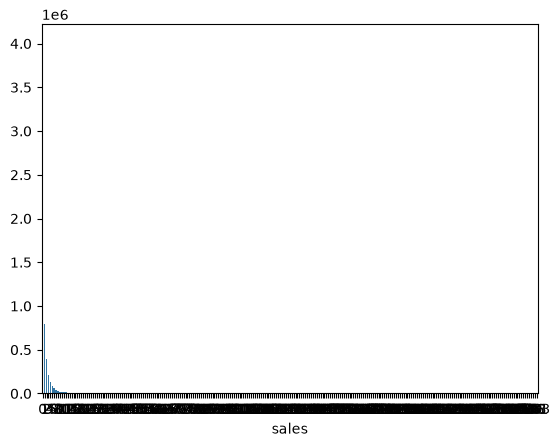

In [6]:
sales_counts = df_sample['sales'].value_counts()
sns.barplot(
    x=sales_counts.index,
    y=sales_counts.values
)
plt.show()

In [7]:
print(f"Zero sales: {(df_sample['sales'] == 0).sum() / len(df_sample) * 100:.2f}%")
print(df_sample['sales'].describe())

Zero sales: 67.99%
count    5918109.0
mean      1.130363
std       3.874199
min            0.0
25%            0.0
50%            0.0
75%            1.0
max          763.0
Name: sales, dtype: Float64


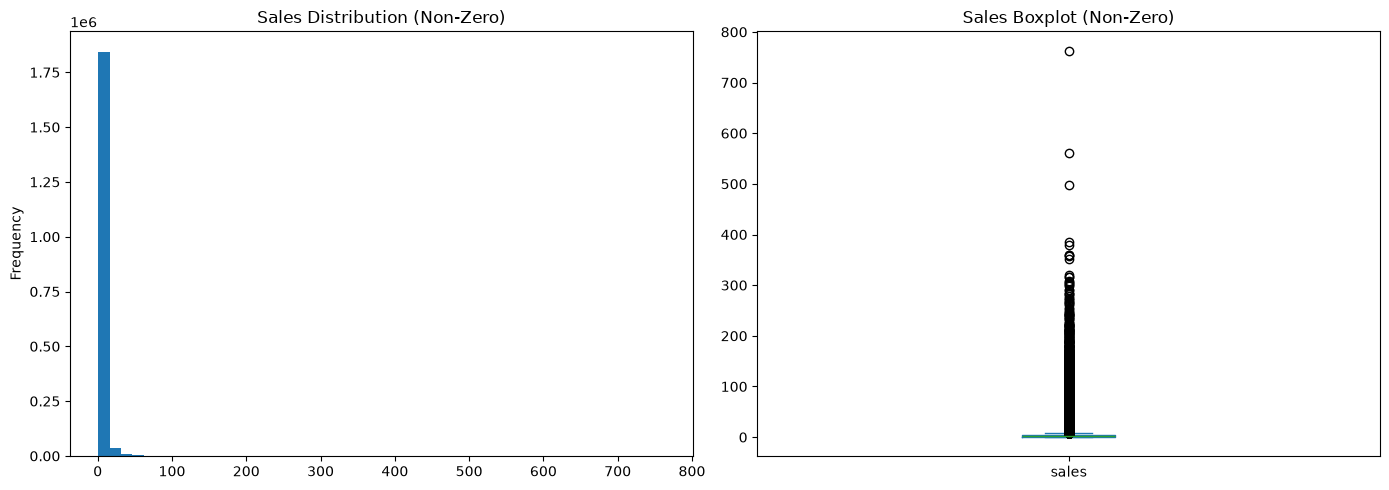

In [8]:
non_zero = df_sample[df_sample['sales'] > 0]['sales']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

non_zero.plot(kind='hist', bins=50, ax=axes[0], title='Sales Distribution (Non-Zero)')
non_zero.plot(kind='box', ax=axes[1], title='Sales Boxplot (Non-Zero)')
plt.tight_layout()
plt.show()

#### Observations: 
1. 67.99% of all sales records are zero — severe zero-inflation
2. Median = 0, meaning more than 50% of items have no sales on any given day
3. 75% of non-zero sales fall between 1 and ~20 units
4. Distribution is heavily right-skewed with a long tail
5. Outliers exist above 300 units, with a max of 763
6. High outliers are likely FOOD items during SNAP days

In [9]:
df_sample.isna().sum()

item_store_id        0
item_id              0
dept_id              0
cat_id               0
store_id             0
state_id             0
day_number           0
sales                0
date                 0
walmart_year_week    0
weekday              0
event_name           0
event_type           0
snap_CA              0
snap_TX              0
snap_WI              0
month_name           0
sell_price           0
dtype: int64

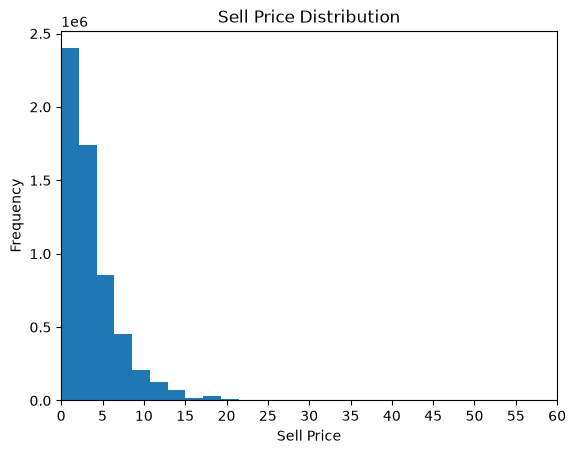

In [10]:
plt.hist(df_sample['sell_price'], bins=50)
plt.title('Sell Price Distribution')
plt.xlabel('Sell Price')
plt.xlim(0, 60)
plt.xticks(range(0, 61, 5))
plt.ylabel('Frequency')
plt.show()

#### Observations

- Most properties have a selling price between 0 and 5.
- The frequency drops sharply after a selling price of 5.
- Very few properties have a selling price above 15.
- Almost no properties have a selling price greater than 20.
- The distribution is heavily right-skewed, with most observations concentrated at lower selling prices.

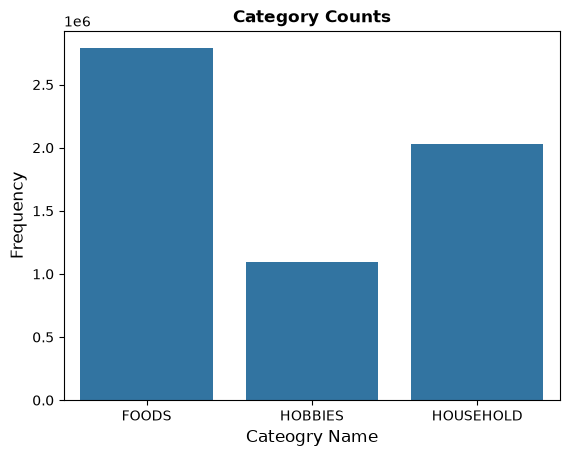

In [11]:
cat_id_counts = df_sample['cat_id'].value_counts()
sns.barplot(x=cat_id_counts.index, y=cat_id_counts.values)
set_labels('Category Counts', xlabel='Cateogry Name')
plt.show()

#### Observations
- `FOODS` is the most frequent category, with over 2.5 million records.
- `HOUSEHOLD` follows with approximately 2.0 million records.
- `HOBBIES` has the lowest count, with around 1.0 million records.
- Overall, `FOODS` significantly outnumbers both `HOUSEHOLD` and `HOBBIES`.

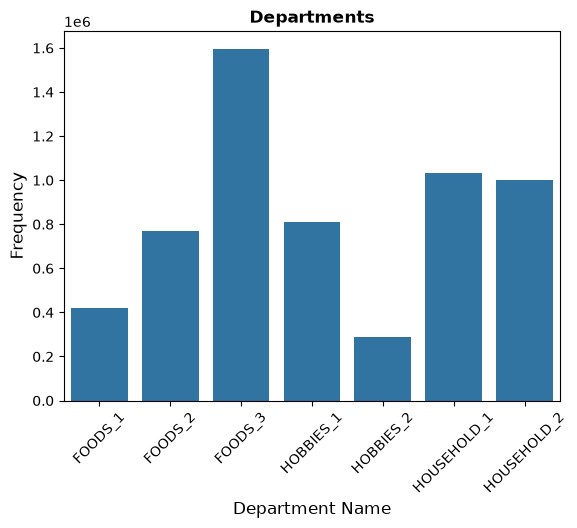

In [12]:
dept_id_counts = df_sample['dept_id'].value_counts()

sns.barplot(
    x=dept_id_counts.index,
    y=dept_id_counts.values
)
set_labels(title='Departments', xlabel='department name')
plt.xticks(rotation=45)
plt.show()

#### Observations

- `FOODS_3` has the highest number of records, with approximately 1.6 million observations.
- `HOBBIES_2` has the fewest records, with around 0.3 million observations.
- `HOUSEHOLD_1` and `HOUSEHOLD_2` have similar record counts, each close to 1.0 million.
- `FOODS_1` contains approximately 0.4 million records.
- `HOBBIES_1` and `FOODS_2` have nearly identical record counts, at around 0.75 million each.
- Overall, record counts vary considerably across categories, with `FOODS_3` dominating the distribution.

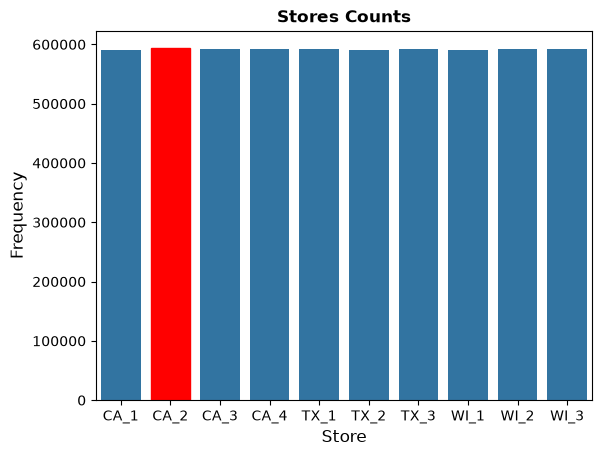

In [13]:
from utils.visualization_utils import highlight_max_bar
# store_id counts
store_counts = df_sample['store_id'].value_counts()
fig, ax = plt.subplots()

sns.barplot(
    x=store_counts.index,
    y=store_counts.values
)
highlight_max_bar(ax)
set_labels(title='Stores Counts', xlabel='store')
plt.show()

#### Observations

- `CA_2` has the highest number of records, with approximately 593.6 thousand observations.
- `TX_2` has the lowest number of records, with approximately 591.1 thousand observations.
- The record counts are remarkably similar across all stores, ranging from about 591 thousand to 594 thousand.
- The difference between the most represented store (`CA_2`) and the least represented store (`TX_2`) is relatively small.
- Overall, the dataset appears to be well-balanced across store locations, with no store significantly dominating the distribution.

In [14]:
store_counts

store_id
CA_2    593624
TX_3    592256
WI_3    592162
CA_3    592068
CA_4    591563
WI_2    591489
TX_1    591423
CA_1    591269
WI_1    591132
TX_2    591123
Name: count, dtype: int64

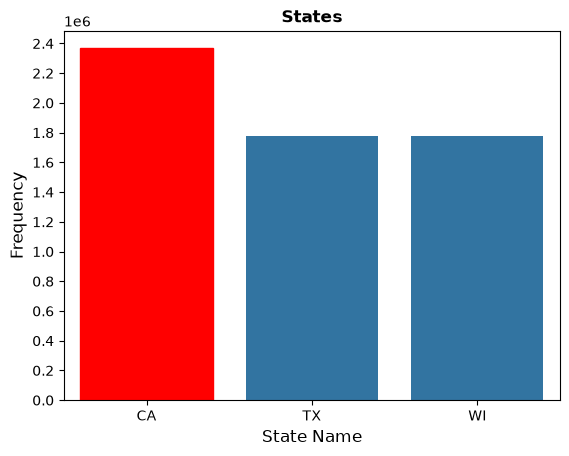

In [20]:
state_counts = df_sample['state_id'].value_counts()
fig, ax = plt.subplots()
sns.barplot(
    x=state_counts.index,
    y=state_counts.values
)
highlight_max_bar(ax)
plt.yticks(range(0, 2500000, 200000))
set_labels("States", 'State name')

#### Observations

- `CA` has the highest number of records, with approximately 2.3 million observations.
- `TX` and `WI` have nearly identical record counts, with about 1.77 million observations each.
- `CA` contains substantially more records than either `TX` or `WI`.

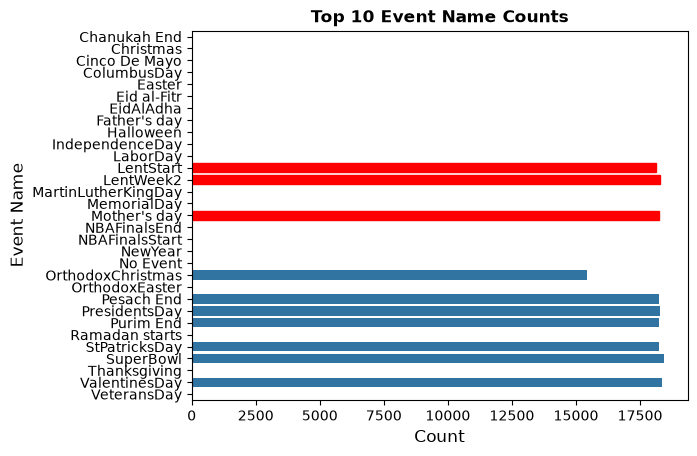

In [ ]:
event_name_counts = df_sample[df_sample['event_name'] != "No Event"]['event_name'].value_counts().head(10)
fig, ax = plt.subplots()
sns.barplot(
    x=event_name_counts.values,
    y=event_name_counts.index,
    ax=ax
)
highlight_max_bar(ax)
set_labels("Top 10 Event Name Counts", xlabel="Count", ylabel="Event Name")
plt.savefig(f'{BASE_PATH}/outputs/univariate_analysis/event_name_counts')
plt.show()

In [29]:
event_name_counts

event_name
SuperBowl            18438
ValentinesDay        18346
LentWeek2            18273
PresidentsDay        18261
Purim End            18250
Mother's day         18247
StPatricksDay        18235
Pesach End           18226
LentStart            18106
OrthodoxChristmas    15432
Name: count, dtype: int64

#### Observations

- `SuperBowl` has the highest number of records, with approximately 18.4 thousand observations.
- `OrthodoxChristmas` has the fewest records among the top events, with around 15.4 thousand observations.
- Most events have very similar record counts, ranging between 18.1 thousand and 18.4 thousand.
- The difference in record counts across the majority of events is relatively small, indicating a fairly balanced distribution.
- `OrthodoxChristmas` stands out as having noticeably fewer records compared to the other events.